In [ ]:
%pip install importlib-resources

In [ ]:
!pip install datasets

import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from datasets import load_dataset
import numpy as np
from sklearn.model_selection import train_test_split
import time

print("Downloading 13-Band Multispectral Dataset...")
hf_dataset = load_dataset("giswqs/EuroSAT_MS", split="train") #
classes = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
           'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'] #

# 1. PyTorch Dataset Wrapper to compute NDVI and create 14 channels
class TrueMultispectralDataset(torch.utils.data.Dataset):
    def __init__(self, hf_data, indices):
        self.hf_data = hf_data
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        sample = self.hf_data[real_idx]

        # Hugging Face provides image as shape (13, 64, 64) in uint16
        img_np = np.array(sample["image"], dtype=np.float32)
        img_tensor = torch.tensor(img_np)

        # Scale uint16 to standard float range (approximate scaling for Sentinel-2)
        img_tensor = img_tensor / 10000.0

        # Calculating NDVI: Band 8 (Index 7) is NIR, Band 4 (Index 3) is Red
        nir = img_tensor[7, :, :]
        red = img_tensor[3, :, :]
        ndvi = (nir - red) / (nir + red + 1e-6)

        # Concatenate 13 bands + 1 NDVI band = 14 Channels total
        tensor_14ch = torch.cat([img_tensor, ndvi.unsqueeze(0)], dim=0)

        return tensor_14ch, sample["label"]

from sklearn.model_selection import GroupKFold

# Creating artificial spatial blocks/zones to simulate geographic tiles
# Assuming every 100 contiguous images come from the same geographic region
group_size = 100
groups = np.arange(len(hf_dataset)) // group_size

gkf = GroupKFold(n_splits=5)

# Generating train and test indices that strictly respect spatial group boundaries
train_idx_spatial, test_idx_spatial = next(
    gkf.split(np.arange(len(hf_dataset)), labels, groups=groups)
)

train_ds_spatial = TrueMultispectralDataset(hf_dataset, train_idx_spatial)
test_ds_spatial = TrueMultispectralDataset(hf_dataset, test_idx_spatial)

# Loaders
train_dl_ms = DataLoader(train_ds_spatial, batch_size=64, shuffle=True, num_workers=2)
test_dl_ms = DataLoader(test_ds_spatial, batch_size=64, shuffle=False, num_workers=2)

print("Spatial Cross-Validation Data Loaders Ready!")

# 2. Defining 14-Channel ResNet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_multispectral_model():
    m = models.resnet18(weights=None)
    # Modifying first conv layer for 14 channels (13 bands + 1 NDVI)
    m.conv1 = nn.Conv2d(14, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc = nn.Linear(m.fc.in_features, len(classes))
    return m.to(device)

# 3. Faster Training Loop for 5 Epochs
model_ms = make_multispectral_model()
optimizer = torch.optim.AdamW(model_ms.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()

print("Training Multispectral ResNet18 from scratch...")
t0 = time.time()
for ep in range(5):
    model_ms.train()
    total_loss = 0.0
    for x, y in train_dl_ms:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_ms(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)

    model_ms.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_dl_ms:
            preds = model_ms(x.to(device)).argmax(1)
            correct += (preds == y.to(device)).sum().item()
            total += len(y)

    acc = correct / total
    print(f"Epoch {ep+1}: train loss {total_loss/len(train_ds_ms):.4f} test acc {acc:.4f}")

print(f"Finished in {time.time()-t0:.0f}s")

Spatial Cross-Validation Data Loaders Ready!
Training Multispectral ResNet18 from scratch...
Epoch 1: train loss 0.5885 test acc 0.6776
Epoch 2: train loss 0.3500 test acc 0.8553
Epoch 3: train loss 0.2732 test acc 0.7439
Epoch 4: train loss 0.2109 test acc 0.8232
Epoch 5: train loss 0.1798 test acc 0.7732
Finished in 492s


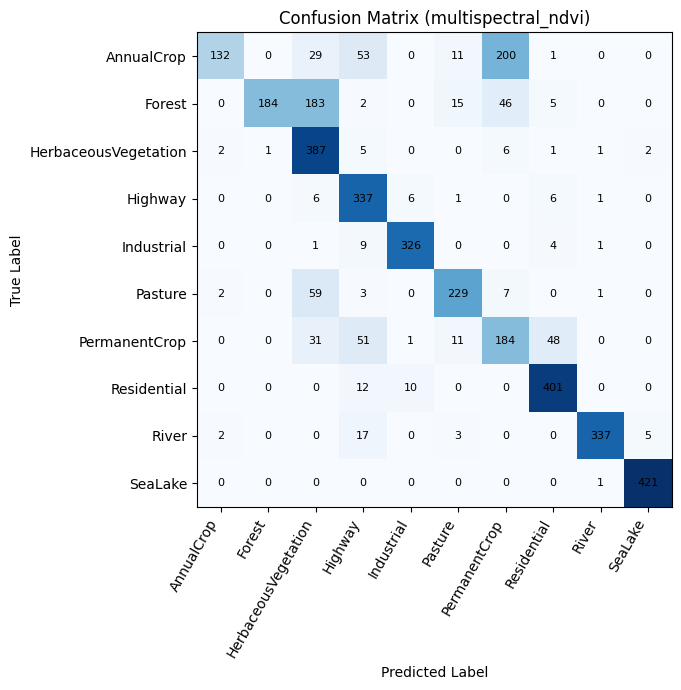


--- Classification Report ---
                      precision    recall  f1-score   support

          AnnualCrop     0.9565    0.3099    0.4681       426
              Forest     0.9946    0.4230    0.5935       435
HerbaceousVegetation     0.5560    0.9556    0.7030       405
             Highway     0.6892    0.9440    0.7967       357
          Industrial     0.9504    0.9560    0.9532       341
             Pasture     0.8481    0.7608    0.8021       301
       PermanentCrop     0.4153    0.5644    0.4785       326
         Residential     0.8605    0.9480    0.9021       423
               River     0.9854    0.9258    0.9547       364
             SeaLake     0.9836    0.9976    0.9906       422

            accuracy                         0.7732      3800
           macro avg     0.8240    0.7785    0.7643      3800
        weighted avg     0.8326    0.7732    0.7622      3800



In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Predictions across the test set
@torch.no_grad()
def predict_multispectral(model, dl):
    model.eval()
    y_true, y_pred = [], []
    for x, y in dl:
        preds = model(x.to(device)).argmax(dim=1).cpu()
        y_pred.append(preds)
        y_true.append(y)
    return torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()

yt_ms, yp_ms = predict_multispectral(model_ms, test_dl_ms)

# 2. Plotting
def show_cm(y_true, y_pred, title="multispectral_ndvi"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(cm, cmap="Blues")

    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=60, ha="right")
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)

    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"Confusion Matrix ({title})")
    plt.tight_layout()
    plt.savefig(f"confusion_{title}.png", dpi=150)
    plt.show()

# 3. Generating a visual plot and a text report
show_cm(yt_ms, yp_ms, "multispectral_ndvi")
print("\n--- Classification Report ---")
print(classification_report(yt_ms, yp_ms, target_names=classes, digits=4))